<a href="https://colab.research.google.com/github/Kaori-Sensei/Amage-Analysis/blob/main/Analisis_de_imaegn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autor del script:** Luis Alberto Castillo Sanabria


========== RESULTADOS ==========
Imagen 1: /content/imagen IA PI.png
Imagen 2: /content/imagen original PI.png
SSIM: 0.5069
Similitud aproximada: 50.69%
Porcentaje visual alterado: 17.43%
Inferencia heurística: La Imagen 2 parece más probable como original
Textura/nitidez Imagen 1 (Laplaciano): 271.25
Textura/nitidez Imagen 2 (Laplaciano): 531.80
Resultados guardados en: /content/drive/MyDrive/comparacion_imagenes/resultados


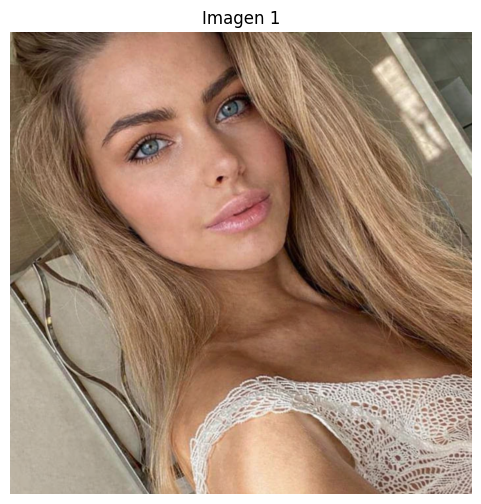

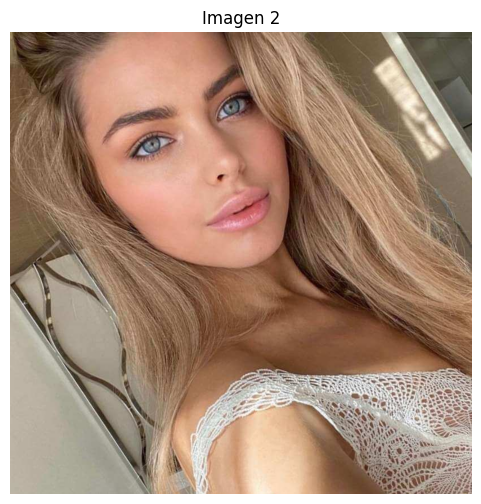

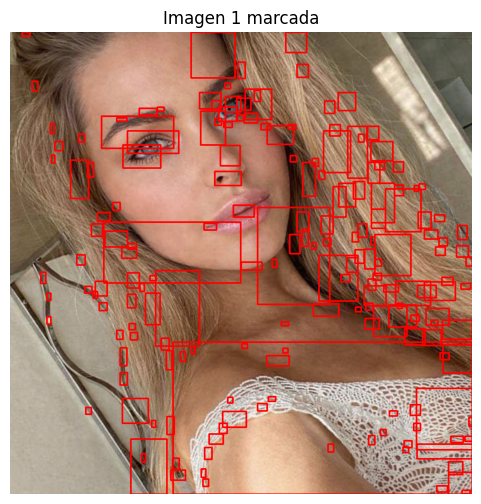

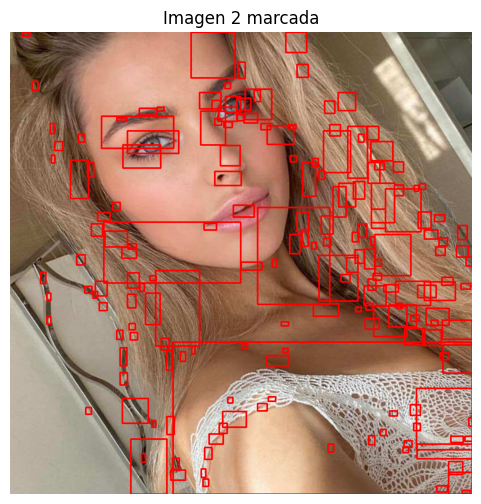

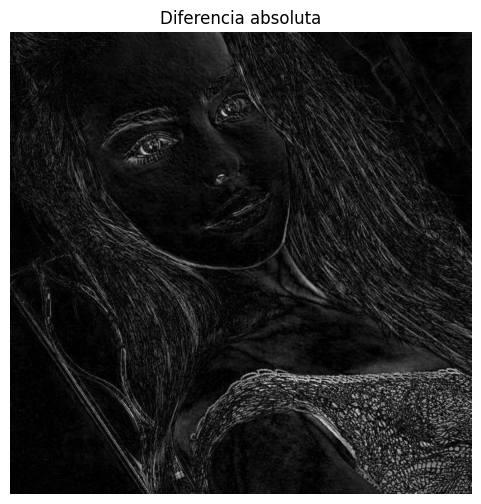

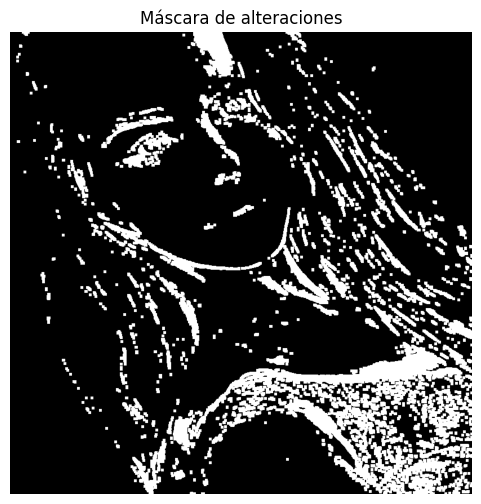

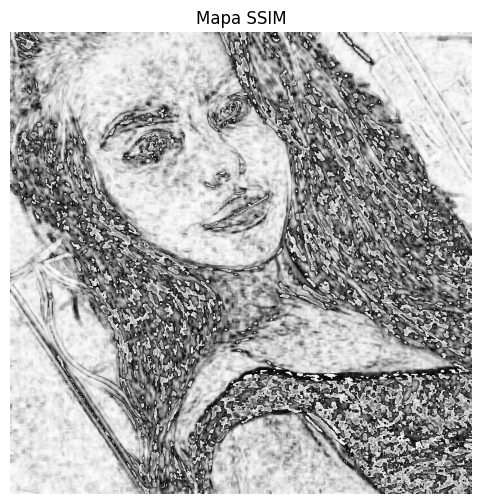

In [ ]:
# ==============================
# COMPARADOR DE IMÁGENES DESDE GOOGLE DRIVE
# ==============================

# 1) Instalar dependencias
!pip install opencv-python scikit-image matplotlib --quiet

# 2) Importar librerías
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

from google.colab import drive
from skimage.metrics import structural_similarity as ssim

# 3) Montar Google Drive
#drive.mount('/content/drive')

# 4) FUNCIONES

def resize_to_same(img1, img2):
    """
    Ajusta ambas imágenes al mismo tamaño usando
    el menor ancho y alto común.
    """
    h = min(img1.shape[0], img2.shape[0])
    w = min(img1.shape[1], img2.shape[1])
    img1_r = cv2.resize(img1, (w, h))
    img2_r = cv2.resize(img2, (w, h))
    return img1_r, img2_r

def estimate_original_by_texture(img1, img2):
    """
    Heurística simple:
    la imagen con más detalle fino y menos suavizado
    puede parecer más cercana a la original.

    Ojo: esto NO demuestra cuál es la original.
    Solo da una inferencia aproximada.
    """
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    lap1 = cv2.Laplacian(gray1, cv2.CV_64F).var()
    lap2 = cv2.Laplacian(gray2, cv2.CV_64F).var()

    if lap1 > lap2:
        guess = "La Imagen 1 parece más probable como original"
    elif lap2 > lap1:
        guess = "La Imagen 2 parece más probable como original"
    else:
        guess = "No se puede inferir cuál es la original"

    return guess, lap1, lap2

def show_image(title, image, cmap=None):
    plt.figure(figsize=(6, 6))
    plt.title(title)
    plt.axis("off")
    plt.imshow(image, cmap=cmap)
    plt.show()

def compare_images(image1_path, image2_path, output_dir):
    """
    Compara dos imágenes y guarda resultados.
    """
    os.makedirs(output_dir, exist_ok=True)

    # Leer imágenes
    img1 = cv2.imread(image1_path)
    img2 = cv2.imread(image2_path)

    if img1 is None:
        raise FileNotFoundError(f"No se pudo leer la imagen 1: {image1_path}")
    if img2 is None:
        raise FileNotFoundError(f"No se pudo leer la imagen 2: {image2_path}")

    # Igualar tamaño
    img1, img2 = resize_to_same(img1, img2)

    # Convertir a escala de grises
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # SSIM
    ssim_score, diff_map = ssim(gray1, gray2, full=True)
    diff_map_uint8 = (diff_map * 255).astype("uint8")

    # Diferencia absoluta
    abs_diff = cv2.absdiff(gray1, gray2)

    # Umbral de cambio
    _, thresh = cv2.threshold(abs_diff, 25, 255, cv2.THRESH_BINARY)

    # Limpieza morfológica
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_DILATE, kernel, iterations=1)

    # Porcentaje de cambio
    altered_pixels = np.count_nonzero(thresh)
    total_pixels = thresh.shape[0] * thresh.shape[1]
    altered_percent = (altered_pixels / total_pixels) * 100

    # Encontrar regiones alteradas
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    marked1 = img1.copy()
    marked2 = img2.copy()

    for c in contours:
        area = cv2.contourArea(c)
        if area > 50:
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(marked1, (x, y), (x + w, y + h), (0, 0, 255), 2)
            cv2.rectangle(marked2, (x, y), (x + w, y + h), (0, 0, 255), 2)

    # Inferencia de original
    guess, lap1, lap2 = estimate_original_by_texture(img1, img2)

    # Convertir a RGB para mostrar con matplotlib
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    marked1_rgb = cv2.cvtColor(marked1, cv2.COLOR_BGR2RGB)
    marked2_rgb = cv2.cvtColor(marked2, cv2.COLOR_BGR2RGB)

    # Guardar imágenes
    cv2.imwrite(os.path.join(output_dir, "01_imagen1_ajustada.png"), img1)
    cv2.imwrite(os.path.join(output_dir, "02_imagen2_ajustada.png"), img2)
    cv2.imwrite(os.path.join(output_dir, "03_imagen1_marcada.png"), marked1)
    cv2.imwrite(os.path.join(output_dir, "04_imagen2_marcada.png"), marked2)
    cv2.imwrite(os.path.join(output_dir, "05_diferencia_absoluta.png"), abs_diff)
    cv2.imwrite(os.path.join(output_dir, "06_mascara_alteraciones.png"), thresh)
    cv2.imwrite(os.path.join(output_dir, "07_mapa_ssim.png"), diff_map_uint8)

    # Guardar resumen en txt
    with open(os.path.join(output_dir, "resumen_resultados.txt"), "w", encoding="utf-8") as f:
        f.write("========== RESULTADOS ==========\n")
        f.write(f"Imagen 1: {image1_path}\n")
        f.write(f"Imagen 2: {image2_path}\n")
        f.write(f"SSIM: {ssim_score:.4f}\n")
        f.write(f"Similitud aproximada: {ssim_score * 100:.2f}%\n")
        f.write(f"Porcentaje visual alterado: {altered_percent:.2f}%\n")
        f.write(f"Inferencia heurística: {guess}\n")
        f.write(f"Textura/nitidez Imagen 1 (Laplaciano): {lap1:.2f}\n")
        f.write(f"Textura/nitidez Imagen 2 (Laplaciano): {lap2:.2f}\n")

    # Mostrar resultados
    print("========== RESULTADOS ==========")
    print(f"Imagen 1: {image1_path}")
    print(f"Imagen 2: {image2_path}")
    print(f"SSIM: {ssim_score:.4f}")
    print(f"Similitud aproximada: {ssim_score * 100:.2f}%")
    print(f"Porcentaje visual alterado: {altered_percent:.2f}%")
    print(f"Inferencia heurística: {guess}")
    print(f"Textura/nitidez Imagen 1 (Laplaciano): {lap1:.2f}")
    print(f"Textura/nitidez Imagen 2 (Laplaciano): {lap2:.2f}")
    print(f"Resultados guardados en: {output_dir}")
    print("================================")

    show_image("Imagen 1", img1_rgb)
    show_image("Imagen 2", img2_rgb)
    show_image("Imagen 1 marcada", marked1_rgb)
    show_image("Imagen 2 marcada", marked2_rgb)
    show_image("Diferencia absoluta", abs_diff, cmap="gray")
    show_image("Máscara de alteraciones", thresh, cmap="gray")
    show_image("Mapa SSIM", diff_map_uint8, cmap="gray")

    return {
        "ssim_score": ssim_score,
        "similarity_percent": ssim_score * 100,
        "altered_percent": altered_percent,
        "original_guess": guess,
        "laplacian_img1": lap1,
        "laplacian_img2": lap2,
        "output_dir": output_dir
    }

# 5) RUTAS DE TUS IMÁGENES EN DRIVE
# Ajusta estas rutas exactamente como estén en tu Drive

image1_path = "/content/imagen IA PI.png"
image2_path = "/content/imagen original PI.png"

# Carpeta de salida
output_dir = "/content/drive/MyDrive/comparacion_imagenes/resultados"

# 6) Ejecutar comparación
resultados = compare_images(image1_path, image2_path, output_dir)

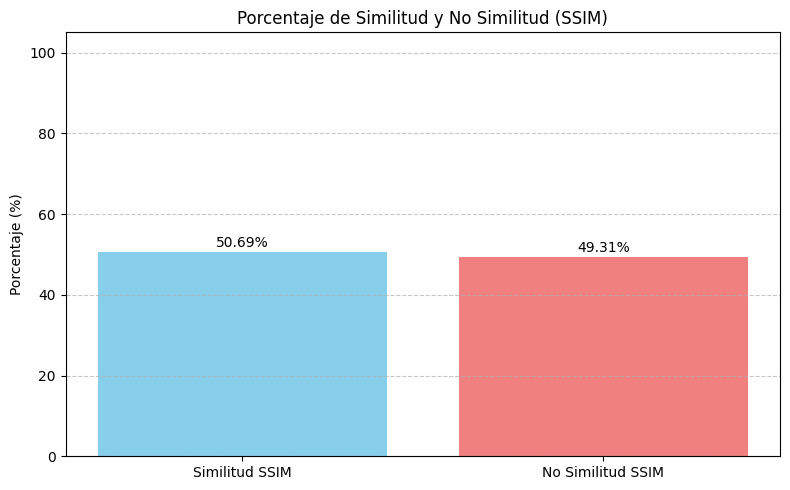

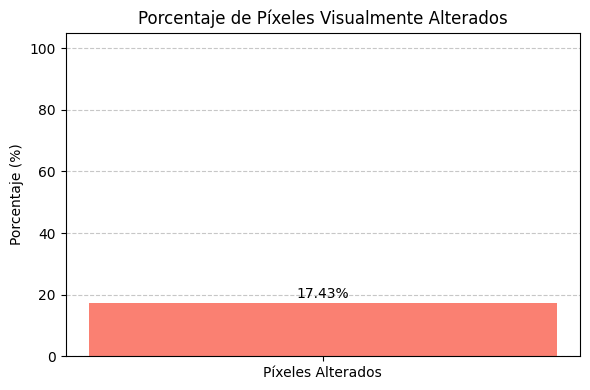

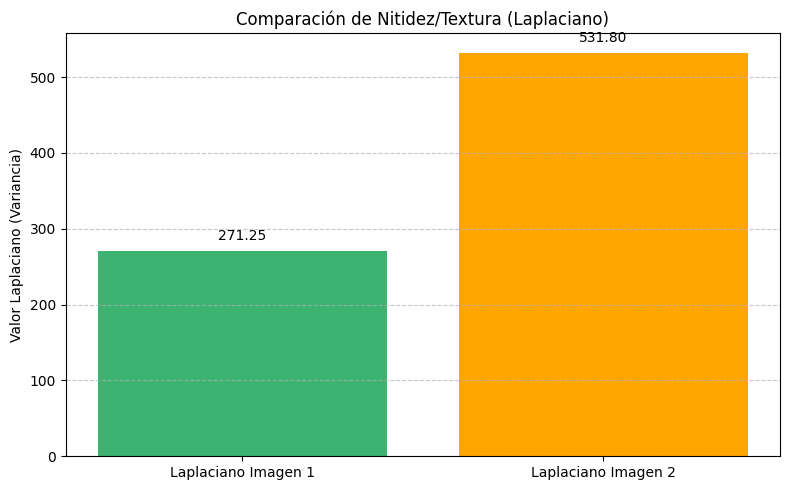

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Asegurarse de que 'resultados' está disponible, si no se ejecutó la celda anterior.
# En este caso, asumimos que 'resultados' ya está en el kernel del usuario.
if 'resultados' not in locals():
    print("Error: La variable 'resultados' no está definida. Por favor, ejecuta la celda anterior.")
else:
    ssim_similarity = resultados['similarity_percent']
    ssim_non_similarity = 100 - ssim_similarity # Calculado directamente
    altered_pixels_percent = resultados['altered_percent']
    laplacian_img1 = resultados['laplacian_img1']
    laplacian_img2 = resultados['laplacian_img2']

    # --- Figura 1: Porcentaje de Similitud y No Similitud (SSIM) ---
    labels = ['Similitud SSIM', 'No Similitud SSIM']
    values = [ssim_similarity, ssim_non_similarity]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=['skyblue', 'lightcoral'])
    plt.ylabel('Porcentaje (%)')
    plt.title('Porcentaje de Similitud y No Similitud (SSIM)')
    for i, v in enumerate(values):
        plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', va='bottom')
    plt.ylim(0, 105) # Ajustar el límite y para mejor visualización
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Figura 2: Porcentaje de Píxeles Visualmente Alterados ---
    plt.figure(figsize=(6, 4))
    plt.bar(['Píxeles Alterados'], [altered_pixels_percent], color='salmon')
    plt.ylabel('Porcentaje (%)')
    plt.title('Porcentaje de Píxeles Visualmente Alterados')
    plt.text(0, altered_pixels_percent + 0.5, f"{altered_pixels_percent:.2f}%", ha='center', va='bottom')
    plt.ylim(0, 105)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Figura 3: Comparación de Nitidez/Textura (Laplaciano) ---
    # Valores más altos indican más detalle/nitidez.
    labels_laplacian = ['Laplaciano Imagen 1', 'Laplaciano Imagen 2']
    values_laplacian = [laplacian_img1, laplacian_img2]

    plt.figure(figsize=(8, 5))
    plt.bar(labels_laplacian, values_laplacian, color=['mediumseagreen', 'orange'])
    plt.ylabel('Valor Laplaciano (Variancia)')
    plt.title('Comparación de Nitidez/Textura (Laplaciano)')
    for i, v in enumerate(values_laplacian):
        plt.text(i, v + (max(values_laplacian)*0.02), f"{v:.2f}", ha='center', va='bottom')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()